# Day 3：从零手写 DQN（本周第一个实践！）

> **目标**：从零实现完整的 DQN 系统——`ReplayBuffer → DQN 网络 → ε-greedy 选动作 → 训练循环`，在 CartPole-v1 上训练成功（稳定 >400 分），并可视化训练过程。

---

## 实现路线图

```
Part 1: 环境搭建与探索
  安装 Gymnasium → CartPole-v1 基本交互 → 随机策略 baseline

Part 2: ReplayBuffer
  经验存储 → 随机采样 → batch 化

Part 3: DQN 网络
  状态(4维) → MLP → Q值(2维)

Part 4: DQN Agent
  ε-greedy 选动作 → 训练循环 → 目标网络同步

Part 5: 训练与可视化
  训练 500 episodes → 奖励曲线 → loss 曲线 → ε 衰减曲线

Part 6: 评估与分析
  贪心策略评估 → 消融实验 → 总结
```

In [1]:
import random
import math
from collections import deque, namedtuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

try:
    import gymnasium as gym
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gymnasium'])
    import gymnasium as gym

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 2.0 MB/s  0:00:0036m-:--:--


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [gymnasium]/3 [gymnasium]


PyTorch version: 2.10.0
CUDA available: True
Using device: cuda


## Part 1：环境探索 — CartPole-v1

CartPole 是经典的 RL 入门环境：一根杆子铰接在小车上，目标是通过左右移动小车来保持杆子直立。

- **状态空间**：4 维连续向量 `[cart_position, cart_velocity, pole_angle, pole_angular_velocity]`
- **动作空间**：2 个离散动作 `{0: 向左, 1: 向右}`
- **奖励**：每一步存活 +1
- **终止条件**：杆子倾斜超过 ±12°、小车偏离超过 ±2.4、或达到 500 步
- **目标**：稳定达到 500 步（满分）

In [2]:
env = gym.make('CartPole-v1')

print(f"观测空间: {env.observation_space}")
print(f"观测空间维度: {env.observation_space.shape[0]}")
print(f"动作空间: {env.action_space}")
print(f"动作数量: {env.action_space.n}")

state, info = env.reset(seed=42)
print(f"\n初始状态: {state}")
print(f"状态含义: [车位置, 车速度, 杆角度, 杆角速度]")

观测空间: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
观测空间维度: 4
动作空间: Discrete(2)
动作数量: 2

初始状态: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
状态含义: [车位置, 车速度, 杆角度, 杆角速度]


In [3]:
# 随机策略 baseline：看看不训练能得多少分
def evaluate_random_policy(env, n_episodes=20):
    rewards = []
    for _ in range(n_episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False
        while not done:
            action = env.action_space.sample()
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated
        rewards.append(total_reward)
    return rewards

random_rewards = evaluate_random_policy(env)
print(f"随机策略: 平均奖励 = {np.mean(random_rewards):.1f} ± {np.std(random_rewards):.1f}")
print(f"  最小 = {min(random_rewards):.0f}, 最大 = {max(random_rewards):.0f}")
print(f"\n目标: 训练 DQN 使平均奖励 > 400")

随机策略: 平均奖励 = 17.6 ± 6.9
  最小 = 9, 最大 = 35

目标: 训练 DQN 使平均奖励 > 400


## Part 2：ReplayBuffer — 经验回放

Day 2 我们学习了经验回放的原理。现在来实现它。

核心功能：
1. `push(s, a, r, s', done)` — 存入一条经验
2. `sample(batch_size)` — 随机采样一个 batch
3. 固定容量，满了就覆盖最旧的数据（FIFO）

In [4]:
Transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done'))


class ReplayBuffer:
    """固定容量的经验回放 Buffer，使用 deque 实现 FIFO。"""

    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append(Transition(state, action, reward, next_state, done))

    def sample(self, batch_size: int):
        transitions = random.sample(self.buffer, batch_size)
        batch = Transition(*zip(*transitions))
        return (
            torch.FloatTensor(np.array(batch.state)).to(device),
            torch.LongTensor(batch.action).to(device),
            torch.FloatTensor(batch.reward).to(device),
            torch.FloatTensor(np.array(batch.next_state)).to(device),
            torch.FloatTensor(batch.done).to(device),
        )

    def __len__(self):
        return len(self.buffer)


# 验证
buf = ReplayBuffer(capacity=1000)
buf.push([1, 2, 3, 4], 0, 1.0, [1, 2, 3, 4], False)
buf.push([5, 6, 7, 8], 1, 0.0, [5, 6, 7, 8], True)
print(f"Buffer 长度: {len(buf)}")
print(f"采样测试通过 ✓")

Buffer 长度: 2
采样测试通过 ✓


## Part 3：DQN 网络

对于 CartPole 这样的低维状态空间（4 维），用 2 层 MLP 即可：

$$
\text{state}(4) \xrightarrow{\text{FC}} 128 \xrightarrow{\text{ReLU}} 128 \xrightarrow{\text{ReLU}} \text{Q values}(2)
$$

输入：状态向量 `(batch, 4)`
输出：每个动作的 Q 值 `(batch, 2)`

In [5]:
class DQN(nn.Module):
    """简单的 2 层 MLP 作为 Q 网络。输入状态，输出每个动作的 Q 值。"""

    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# 验证网络
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

q_net = DQN(state_dim, action_dim).to(device)
dummy_state = torch.randn(1, state_dim).to(device)
q_values = q_net(dummy_state)

print(f"状态维度: {state_dim}")
print(f"动作维度: {action_dim}")
print(f"输入 shape: {dummy_state.shape}")
print(f"输出 shape: {q_values.shape}")
print(f"Q 值: {q_values.detach().cpu().numpy()}")

total_params = sum(p.numel() for p in q_net.parameters())
print(f"参数量: {total_params:,}")

状态维度: 4
动作维度: 2
输入 shape: torch.Size([1, 4])
输出 shape: torch.Size([1, 2])
Q 值: [[0.19812152 0.08649284]]
参数量: 17,410


## Part 4：DQN Agent — 把所有组件组装起来

Agent 封装了：
1. **在线网络** `q_net` 和 **目标网络** `target_net`
2. **ε-greedy 选动作**
3. **训练（learn）**：从 buffer 采样 → 计算 TD target → MSE loss → 更新
4. **目标网络同步**

In [6]:
class DQNAgent:
    """
    完整的 DQN Agent，包含:
    - 在线网络 + 目标网络
    - ε-greedy 探索
    - 经验回放训练
    - 目标网络软更新
    """

    def __init__(
        self,
        state_dim: int,
        action_dim: int,
        hidden_dim: int = 128,
        lr: float = 1e-3,
        gamma: float = 0.99,
        buffer_capacity: int = 10000,
        batch_size: int = 64,
        epsilon_start: float = 1.0,
        epsilon_end: float = 0.01,
        epsilon_decay: int = 5000,
        target_update_freq: int = 200,
    ):
        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size
        self.epsilon_start = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.target_update_freq = target_update_freq

        # 在线网络和目标网络
        self.q_net = DQN(state_dim, action_dim, hidden_dim).to(device)
        self.target_net = DQN(state_dim, action_dim, hidden_dim).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.buffer = ReplayBuffer(buffer_capacity)

        self.steps_done = 0
        self.losses = []

    def get_epsilon(self) -> float:
        """指数衰减的 ε 值。"""
        return self.epsilon_end + (self.epsilon_start - self.epsilon_end) * \
            math.exp(-self.steps_done / self.epsilon_decay)

    @torch.no_grad()
    def select_action(self, state: np.ndarray) -> int:
        """ε-greedy 选动作。"""
        epsilon = self.get_epsilon()
        self.steps_done += 1

        if random.random() < epsilon:
            return random.randrange(self.action_dim)

        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        q_values = self.q_net(state_t)
        return q_values.argmax(dim=1).item()

    def learn(self) -> float:
        """
        从 replay buffer 采样一个 batch，计算 TD loss 并更新网络。
        返回 loss 值。
        """
        if len(self.buffer) < self.batch_size:
            return 0.0

        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)

        # 当前 Q 值: Q_θ(s, a) — 只取实际执行的动作对应的 Q 值
        q_values = self.q_net(states)                           # (batch, action_dim)
        q_values = q_values.gather(1, actions.unsqueeze(1))     # (batch, 1)
        q_values = q_values.squeeze(1)                         # (batch,)

        # TD target: y = r + γ * max_a' Q_{θ⁻}(s', a') * (1 - done)
        with torch.no_grad():
            next_q_values = self.target_net(next_states)        # (batch, action_dim)
            max_next_q = next_q_values.max(dim=1)[0]           # (batch,)
            td_target = rewards + self.gamma * max_next_q * (1 - dones)

        # MSE Loss
        loss = F.mse_loss(q_values, td_target)

        # 反向传播
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_net.parameters(), max_norm=10.0)
        self.optimizer.step()

        loss_val = loss.item()
        self.losses.append(loss_val)

        # 定期同步目标网络
        if self.steps_done % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        return loss_val


print("DQNAgent 定义完成 ✓")

DQNAgent 定义完成 ✓


## Part 5：训练循环

训练流程：
```
For each episode:
  reset 环境
  While not done:
    1. ε-greedy 选动作
    2. 执行动作，获得 (s', r, done)
    3. 存入 buffer
    4. 从 buffer 采样训练
  记录本 episode 的总奖励
```

In [7]:
def train_dqn(env, agent, n_episodes=500, print_every=50):
    """训练 DQN Agent，返回每个 episode 的奖励列表。"""
    episode_rewards = []
    epsilon_history = []

    for episode in range(1, n_episodes + 1):
        state, _ = env.reset()
        total_reward = 0
        done = False

        while not done:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.buffer.push(state, action, reward, next_state, float(done))
            agent.learn()

            state = next_state
            total_reward += reward

        episode_rewards.append(total_reward)
        epsilon_history.append(agent.get_epsilon())

        if episode % print_every == 0:
            avg_reward = np.mean(episode_rewards[-print_every:])
            print(f"Episode {episode:4d} | "
                  f"Avg Reward (last {print_every}): {avg_reward:6.1f} | "
                  f"ε: {agent.get_epsilon():.3f} | "
                  f"Buffer: {len(agent.buffer)}")

    return episode_rewards, epsilon_history


# 设置随机种子保证可复现
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

env = gym.make('CartPole-v1')

agent = DQNAgent(
    state_dim=env.observation_space.shape[0],
    action_dim=env.action_space.n,
    hidden_dim=128,
    lr=1e-3,
    gamma=0.99,
    buffer_capacity=10000,
    batch_size=64,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=3000,
    target_update_freq=200,
)

print("开始训练 DQN...\n")
episode_rewards, epsilon_history = train_dqn(env, agent, n_episodes=500)

开始训练 DQN...

Episode   50 | Avg Reward (last 50):   21.3 | ε: 0.704 | Buffer: 1065
Episode  100 | Avg Reward (last 50):   74.8 | ε: 0.210 | Buffer: 4805
Episode  150 | Avg Reward (last 50):  148.1 | ε: 0.027 | Buffer: 10000
Episode  200 | Avg Reward (last 50):  123.8 | ε: 0.012 | Buffer: 10000
Episode  250 | Avg Reward (last 50):  213.4 | ε: 0.010 | Buffer: 10000
Episode  300 | Avg Reward (last 50):  212.8 | ε: 0.010 | Buffer: 10000
Episode  350 | Avg Reward (last 50):  100.3 | ε: 0.010 | Buffer: 10000
Episode  400 | Avg Reward (last 50):  142.0 | ε: 0.010 | Buffer: 10000
Episode  450 | Avg Reward (last 50):  237.9 | ε: 0.010 | Buffer: 10000
Episode  500 | Avg Reward (last 50):  300.8 | ε: 0.010 | Buffer: 10000


## Part 6：训练曲线可视化

可视化三个关键指标：
1. **Episode 奖励**（含滑动平均）— 学习效果
2. **训练 Loss** — 网络拟合质量
3. **ε 衰减曲线** — 探索率变化

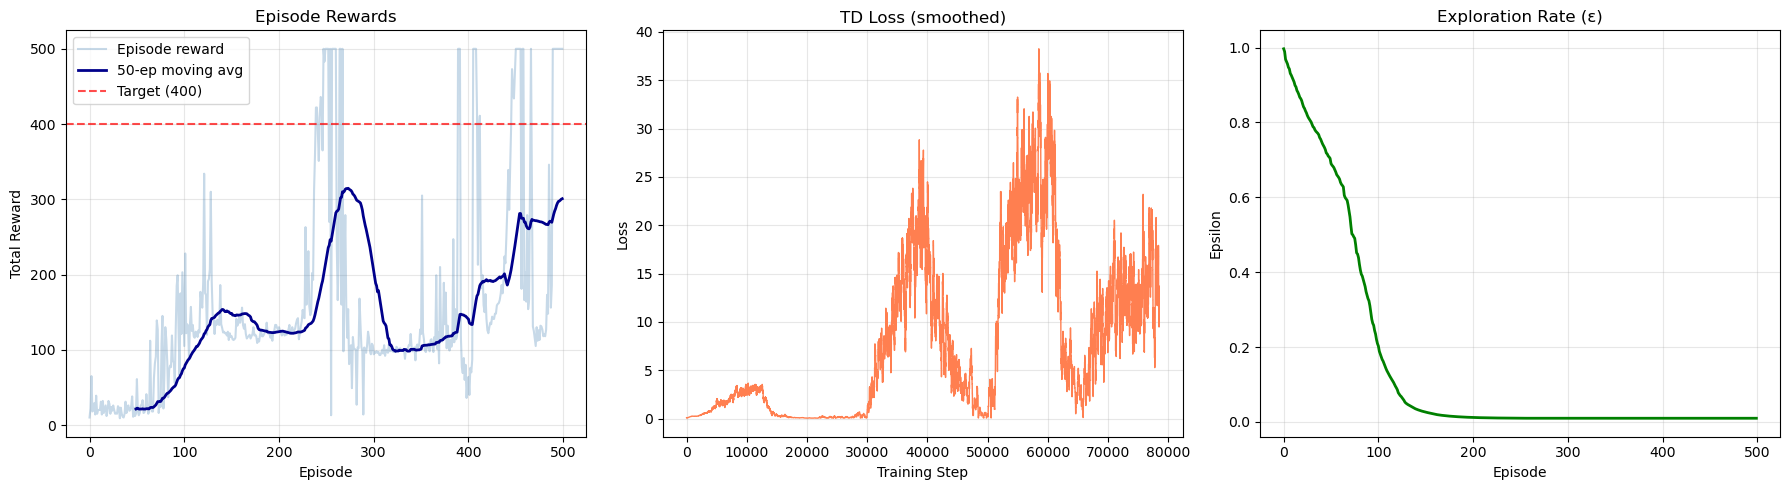

In [8]:
def plot_training_curves(episode_rewards, losses, epsilon_history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Episode 奖励
    ax = axes[0]
    ax.plot(episode_rewards, alpha=0.3, color='steelblue', label='Episode reward')
    window = 50
    if len(episode_rewards) >= window:
        smoothed = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(episode_rewards)), smoothed,
                color='darkblue', linewidth=2, label=f'{window}-ep moving avg')
    ax.axhline(y=400, color='red', linestyle='--', alpha=0.7, label='Target (400)')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.set_title('Episode Rewards')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 2. 训练 Loss
    ax = axes[1]
    if losses:
        loss_window = 200
        if len(losses) >= loss_window:
            smoothed_loss = np.convolve(losses, np.ones(loss_window)/loss_window, mode='valid')
            ax.plot(smoothed_loss, color='coral', linewidth=1)
        else:
            ax.plot(losses, color='coral', alpha=0.5)
    ax.set_xlabel('Training Step')
    ax.set_ylabel('Loss')
    ax.set_title('TD Loss (smoothed)')
    ax.grid(True, alpha=0.3)

    # 3. Epsilon 衰减
    ax = axes[2]
    ax.plot(epsilon_history, color='green', linewidth=2)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Epsilon')
    ax.set_title('Exploration Rate (ε)')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_training_curves(episode_rewards, agent.losses, epsilon_history)

## Part 7：贪心策略评估

训练完成后，用 **ε=0**（纯贪心）策略评估模型真实性能。

In [9]:
@torch.no_grad()
def evaluate_agent(env, agent, n_episodes=20):
    """用贪心策略（无探索）评估 Agent。"""
    rewards = []
    for _ in range(n_episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False
        while not done:
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            q_values = agent.q_net(state_t)
            action = q_values.argmax(dim=1).item()
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated
        rewards.append(total_reward)
    return rewards


eval_rewards = evaluate_agent(env, agent)
print(f"贪心策略评估 ({len(eval_rewards)} episodes):")
print(f"  平均奖励: {np.mean(eval_rewards):.1f} ± {np.std(eval_rewards):.1f}")
print(f"  最小: {min(eval_rewards):.0f}, 最大: {max(eval_rewards):.0f}")
print()
if np.mean(eval_rewards) >= 400:
    print("目标达成! 平均奖励 >= 400 ✓")
else:
    print("未达标，建议增加训练 episode 数或调整超参数")

贪心策略评估 (20 episodes):
  平均奖励: 500.0 ± 0.0
  最小: 500, 最大: 500

目标达成! 平均奖励 >= 400 ✓


## Part 8：Q 值可视化 — 模型学到了什么？

我们来看看训练后的 DQN 在不同状态下学到的 Q 值分布，直观理解它的决策逻辑。

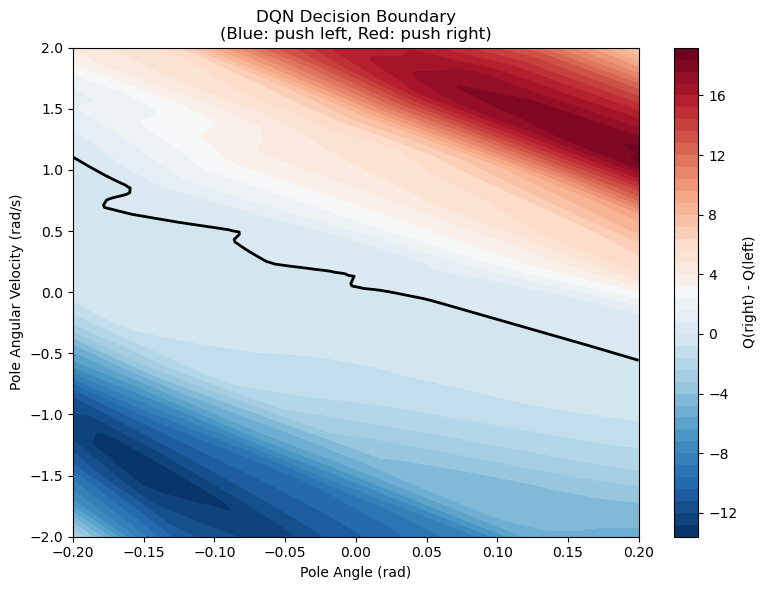

In [10]:
@torch.no_grad()
def visualize_q_values(agent, n_points=200):
    """
    固定车位置和车速度为 0，扫描杆角度和杆角速度，
    可视化 Q(s, 左) - Q(s, 右) 的决策边界。
    """
    angles = np.linspace(-0.2, 0.2, n_points)
    ang_vels = np.linspace(-2, 2, n_points)
    A, AV = np.meshgrid(angles, ang_vels)

    states = np.zeros((n_points * n_points, 4), dtype=np.float32)
    states[:, 2] = A.flatten()   # pole_angle
    states[:, 3] = AV.flatten()  # pole_angular_velocity

    states_t = torch.FloatTensor(states).to(device)
    q_vals = agent.q_net(states_t).cpu().numpy()

    q_diff = (q_vals[:, 1] - q_vals[:, 0]).reshape(n_points, n_points)

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    im = ax.contourf(A, AV, q_diff, levels=50, cmap='RdBu_r')
    ax.contour(A, AV, q_diff, levels=[0], colors='black', linewidths=2)
    plt.colorbar(im, ax=ax, label='Q(right) - Q(left)')
    ax.set_xlabel('Pole Angle (rad)')
    ax.set_ylabel('Pole Angular Velocity (rad/s)')
    ax.set_title('DQN Decision Boundary\n(Blue: push left, Red: push right)')
    plt.tight_layout()
    plt.show()


visualize_q_values(agent)

## Part 9：消融实验 — 经验回放和目标网络有多重要？

为了验证 Day 2 讲的两个关键创新的作用，我们做简单的消融实验。

> 注意：消融实验需要额外训练时间。如果时间紧张，可以只看结论。

In [11]:
class DQNAgentNoTarget(DQNAgent):
    """去掉目标网络：直接用在线网络计算 TD target。"""

    def learn(self) -> float:
        if len(self.buffer) < self.batch_size:
            return 0.0

        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)

        q_values = self.q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            # 关键区别：用在线网络而非目标网络
            max_next_q = self.q_net(next_states).max(dim=1)[0]
            td_target = rewards + self.gamma * max_next_q * (1 - dones)

        loss = F.mse_loss(q_values, td_target)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_net.parameters(), max_norm=10.0)
        self.optimizer.step()

        loss_val = loss.item()
        self.losses.append(loss_val)
        return loss_val


# 训练无目标网络版本
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

env_ablation = gym.make('CartPole-v1')
agent_no_target = DQNAgentNoTarget(
    state_dim=state_dim, action_dim=action_dim,
    hidden_dim=128, lr=1e-3, gamma=0.99,
    buffer_capacity=10000, batch_size=64,
    epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=3000,
    target_update_freq=200,
)

print("训练 DQN（无目标网络）...")
rewards_no_target, _ = train_dqn(env_ablation, agent_no_target, n_episodes=300, print_every=100)

训练 DQN（无目标网络）...
Episode  100 | Avg Reward (last 100):   66.5 | ε: 0.118 | Buffer: 6646
Episode  200 | Avg Reward (last 100):   43.5 | ε: 0.035 | Buffer: 10000
Episode  300 | Avg Reward (last 100):   74.2 | ε: 0.012 | Buffer: 10000


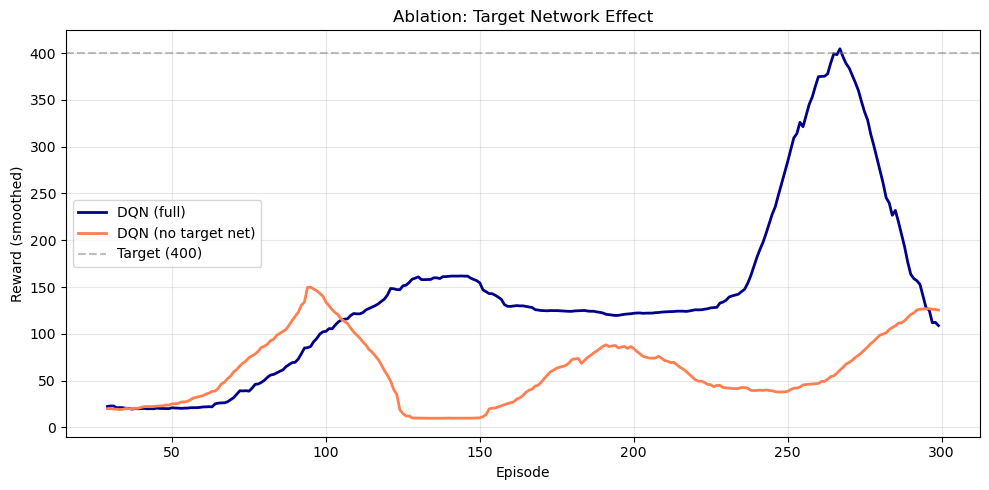

In [12]:
# 对比可视化
fig, ax = plt.subplots(figsize=(10, 5))

window = 30
for rewards, label, color in [
    (episode_rewards[:300], 'DQN (full)', 'darkblue'),
    (rewards_no_target, 'DQN (no target net)', 'coral'),
]:
    if len(rewards) >= window:
        smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(rewards)), smoothed, label=label, color=color, linewidth=2)

ax.axhline(y=400, color='gray', linestyle='--', alpha=0.5, label='Target (400)')
ax.set_xlabel('Episode')
ax.set_ylabel('Reward (smoothed)')
ax.set_title('Ablation: Target Network Effect')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part 10：总结与 Day 4 预告

### 本日回顾

我们从零实现了完整的 DQN 系统：

| 组件 | 作用 |
|------|------|
| `ReplayBuffer` | 存储经验，打破时间相关性 |
| `DQN` (网络) | 用 MLP 逼近 Q 函数 |
| `DQNAgent` | 封装 ε-greedy、训练、目标网络同步 |
| 训练循环 | 交互 → 存储 → 采样 → 更新 |

### DQN 的局限

DQN 虽然强大，但有几个根本性局限：

1. **只能处理离散动作空间** — `argmax` 操作要求枚举所有动作
2. **策略是确定性的** — 无法表达随机策略
3. **间接优化** — 先学 Q，再推导策略，效率不是最优

### Day 4 预告：策略梯度

明天我们将学习一种完全不同的思路：**直接参数化并优化策略** $\pi_\theta(a \mid s)$。

- 不再需要 Q 函数
- 天然支持连续动作空间
- 输出的是概率分布（随机策略）
- 策略梯度定理 → REINFORCE → Actor-Critic → PPO

这条路线最终通向 RLHF 中 LLM 的策略优化。